# Superstore — Retail Performance Analysis
### A Complete Exploratory Data Analysis & Business Intelligence Portfolio Project

---

## 1. Project Introduction

### Dataset Overview
The **Sample Superstore** dataset is a widely-used retail analytics dataset that captures
transactional data from a fictional U.S.-based superstore chain. It contains **9,994 order
records** spanning multiple years across four geographic regions.

| Attribute       | Detail |
|----------------|--------|
| **Records**    | 9,994 rows |
| **Features**   | 13 columns |
| **Domain**     | Retail / E-commerce |
| **Geography**  | United States (4 Regions) |

### Business Objective
This analysis aims to uncover actionable intelligence that enables stakeholders to:
- Identify top-performing and under-performing product categories and sub-categories
- Understand the impact of discounting on profitability
- Detect regional and segment-level performance patterns
- Provide data-driven recommendations to improve margins and reduce losses

### Key Questions to Answer
1. Which **product categories and sub-categories** generate the highest revenue and profit?
2. Which **regions and states** are most and least profitable?
3. How do **discount rates** affect sales and profit margins?
4. Which **customer segments** contribute most to revenue?
5. What are the **shipping mode preferences** and how do they relate to profitability?
6. Are there **seasonal trends** in sales performance?
7. Which **sub-categories are consistently loss-making**?

---


## 2. Import Libraries

In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
})

PALETTE = sns.color_palette("Set2")
print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load Dataset

In [5]:
# Load dataset
FILE_PATH = "./Superstore.csv"
df = pd.read_csv(FILE_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dataset loaded: 9,994 rows × 13 columns


In [6]:
# Preview first 5 rows
df.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [7]:
# Dimensions
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")


Rows    : 9,994
Columns : 13


In [8]:
# Column names 
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")


Columns:
   1. Ship Mode
   2. Segment
   3. Country
   4. City
   5. State
   6. Postal Code
   7. Region
   8. Category
   9. Sub-Category
  10. Sales
  11. Quantity
  12. Discount
  13. Profit


## 4. Data Understanding

In [9]:
# Dataset info 
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [10]:
# Data types per column 
dtype_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().mean() * 100).round(2)
})
dtype_summary


,Data Type,Non-Null Count,Null Count,Null %
Ship Mode,object,9994,0,0.0
Segment,object,9994,0,0.0
Country,object,9994,0,0.0
City,object,9994,0,0.0
State,object,9994,0,0.0
Postal Code,int64,9994,0,0.0
Region,object,9994,0,0.0
Category,object,9994,0,0.0
Sub-Category,object,9994,0,0.0
Sales,float64,9994,0,0.0


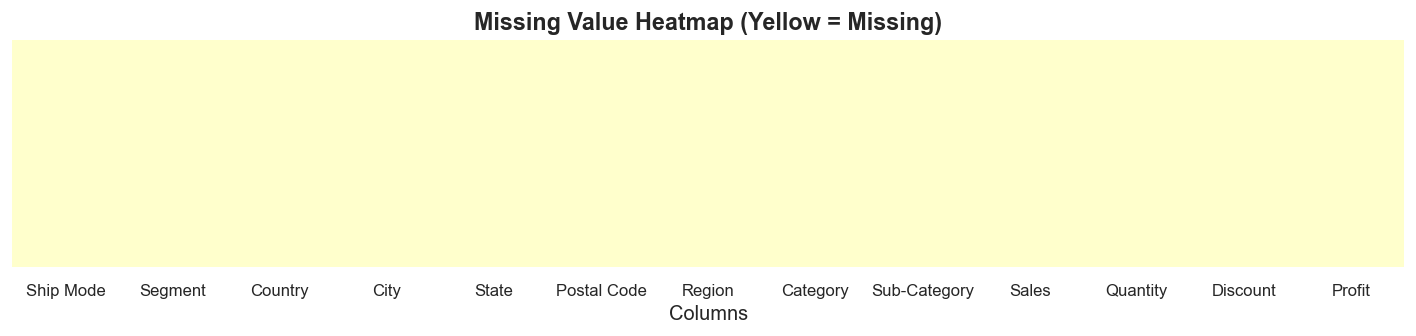


Total missing values: 0


In [11]:
# Missing value heatmap
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap="YlOrRd", ax=ax)
ax.set_title("Missing Value Heatmap (Yellow = Missing)")
ax.set_xlabel("Columns")
plt.tight_layout()
plt.show()
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


In [12]:
# Duplicate records
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")


Duplicate rows found: 17


In [13]:
# Summary statistics for numeric columns
df.describe().T.style.background_gradient(cmap="Blues", axis=1)


,count,mean,std,min,25%,50%,75%,max
Postal Code,9994.000000,55190.379428,32063.693350,1040.000000,23223.000000,56430.500000,90008.000000,99301.000000
Sales,9994.000000,229.858001,623.245101,0.444000,17.280000,54.490000,209.940000,22638.480000
Quantity,9994.000000,3.789574,2.225110,1.000000,2.000000,3.000000,5.000000,14.000000
Discount,9994.000000,0.156203,0.206452,0.000000,0.000000,0.200000,0.200000,0.800000
Profit,9994.000000,28.656896,234.260108,-6599.978000,1.728750,8.666500,29.364000,8399.976000


In [14]:
# Cardinality check for categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"{col:15s} → {df[col].nunique():>4} unique values | "
          f"Top: {df[col].value_counts().index[0]}")


Ship Mode       →    4 unique values | Top: Standard Class
Segment         →    3 unique values | Top: Consumer
Country         →    1 unique values | Top: United States
City            →  531 unique values | Top: New York City
State           →   49 unique values | Top: California
Region          →    4 unique values | Top: West
Category        →    3 unique values | Top: Office Supplies
Sub-Category    →   17 unique values | Top: Binders


## 5. Data Cleaning

### 5.1 — Copy original DataFrame

In [15]:
# Working copy
df_clean = df.copy()
print("Working copy created.")


Working copy created.


### 5.2 — Handle missing values

In [16]:
# Confirm zero missing values
assert df_clean.isnull().sum().sum() == 0, "Unexpected missing values found!"
print("No missing values — no imputation required.")


No missing values — no imputation required.


### 5.3 — Remove duplicate records

In [17]:
# Remove duplicates
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
removed = before - len(df_clean)
print(f"Rows before: {before:,}  |  After: {len(df_clean):,}  |  Removed: {removed}")


Rows before: 9,994  |  After: 9,977  |  Removed: 17


### 5.4 — Fix data types

In [18]:
# Convert Postal Code to string 
df_clean["Postal Code"] = df_clean["Postal Code"].astype(str).str.zfill(5)
print("Postal Code converted to zero-padded string.")
print(df_clean["Postal Code"].head())


Postal Code converted to zero-padded string.
0    42420
1    42420
2    90036
3    33311
4    33311
Name: Postal Code, dtype: object


### 5.5 — Feature engineering
We derive several high-value features that will power the business analysis sections:
- **Profit Margin %** — profitability relative to sales
- **Revenue Band** — categorise orders by sales size
- **Discount Band** — group discount rates into meaningful tiers


In [19]:
# Profit margin (%) 
# Guard against division-by-zero on zero-sales rows (none exist, but best practice)
df_clean["Profit Margin %"] = np.where(
    df_clean["Sales"] != 0,
    (df_clean["Profit"] / df_clean["Sales"] * 100).round(2),
    0.0
)

# Revenue band
df_clean["Revenue Band"] = pd.cut(
    df_clean["Sales"],
    bins=[0, 50, 250, 1000, np.inf],
    labels=["Low (<$50)", "Medium ($50–$250)", "High ($250–$1K)", "Premium (>$1K)"]
)

# Discount band
df_clean["Discount Band"] = pd.cut(
    df_clean["Discount"],
    bins=[-0.01, 0.0, 0.2, 0.4, 0.8],
    labels=["No Discount", "Low (0–20%)", "Medium (20–40%)", "High (40–80%)"]
)

print("Feature engineering complete.")
df_clean[["Sales", "Profit", "Profit Margin %", "Revenue Band",
          "Discount", "Discount Band"]].head()


Feature engineering complete.


,Sales,Profit,Profit Margin %,Revenue Band,Discount,Discount Band
0,261.9600,41.9136,16.00,High ($250–$1K),0.00,No Discount
1,731.9400,219.5820,30.00,High ($250–$1K),0.00,No Discount
2,14.6200,6.8714,47.00,Low (<$50),0.00,No Discount
3,957.5775,-383.0310,-40.00,High ($250–$1K),0.45,High (40–80%)
4,22.3680,2.5164,11.25,Low (<$50),0.20,Low (0–20%)


### 5.6 — Outlier analysis

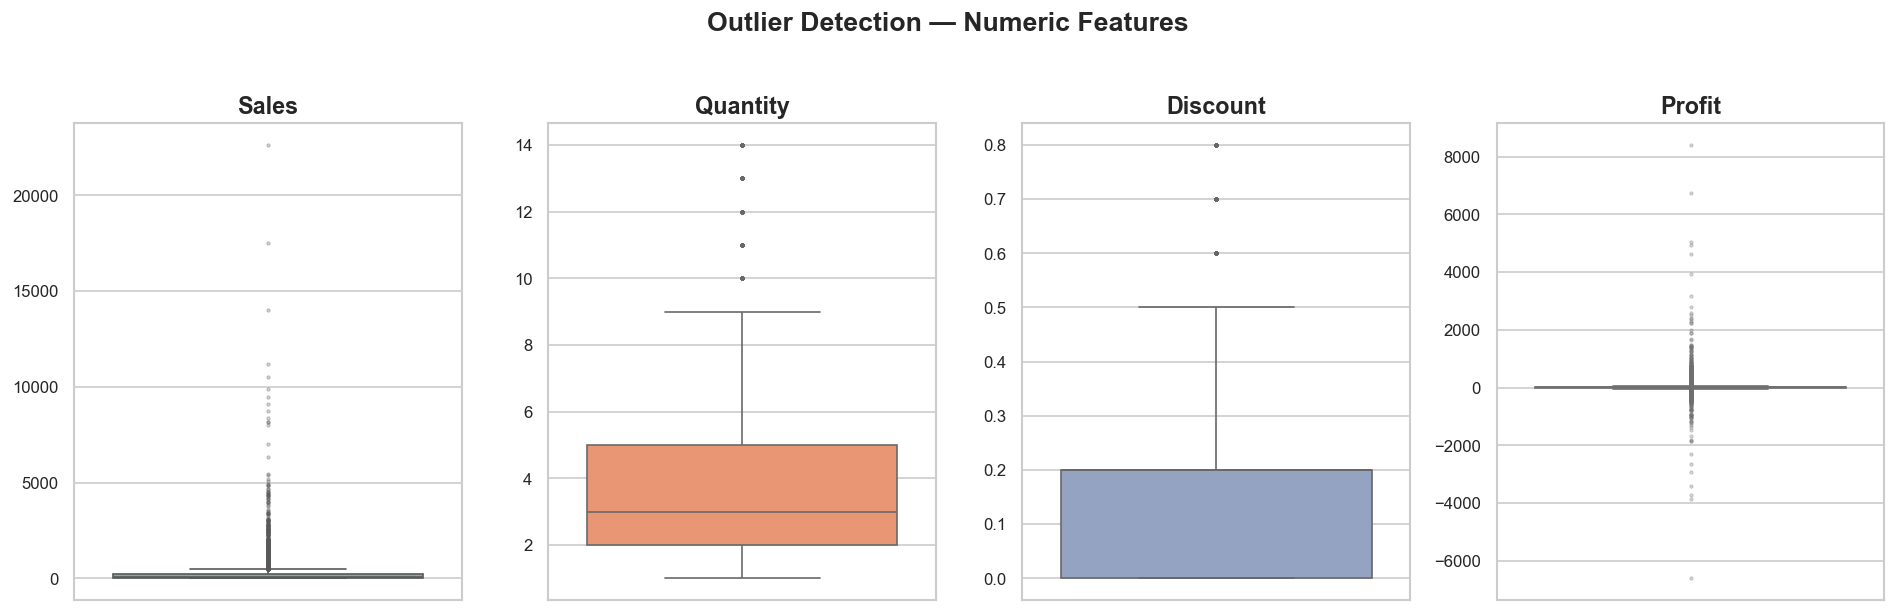

In [20]:
# Outlier box plots
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color=PALETTE[numeric_cols.index(col)],
                flierprops=dict(marker=".", markersize=3, alpha=0.4))
    ax.set_title(col)
    ax.set_ylabel("")

fig.suptitle("Outlier Detection — Numeric Features", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Observation:** `Sales` and `Profit` contain legitimate high-value outliers (large B2B orders).
These represent real business transactions and are retained in the cleaned dataset.


In [21]:
# Cleaned dataset summary
print(f"Cleaned dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Added features : Profit Margin %, Revenue Band, Discount Band")


Cleaned dataset: 9,977 rows × 16 columns
Added features : Profit Margin %, Revenue Band, Discount Band


## 6. Exploratory Data Analysis (EDA)

### 6.1 — Univariate Analysis


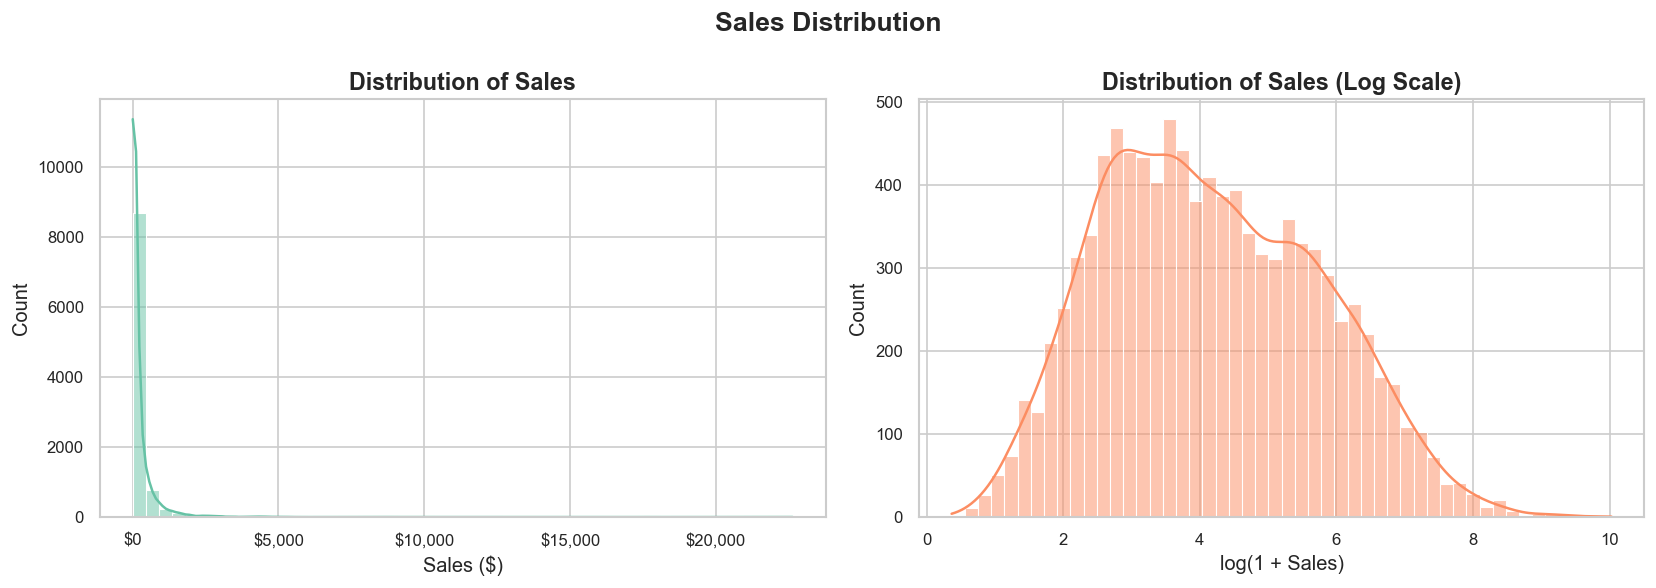

In [22]:
# Distribution of Sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
sns.histplot(df_clean["Sales"], bins=50, kde=True,
             ax=axes[0], color=PALETTE[0])
axes[0].set_title("Distribution of Sales")
axes[0].set_xlabel("Sales ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Log-transformed distribution
sns.histplot(np.log1p(df_clean["Sales"]), bins=50, kde=True,
             ax=axes[1], color=PALETTE[1])
axes[1].set_title("Distribution of Sales (Log Scale)")
axes[1].set_xlabel("log(1 + Sales)")

plt.suptitle("Sales Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight:** Sales are highly right-skewed — the majority of transactions are low-value,
but a tail of high-value orders significantly inflates the mean (~$230) above the median (~$55).
Log-transforming reveals a near-normal distribution, confirming multiplicative dynamics in pricing.


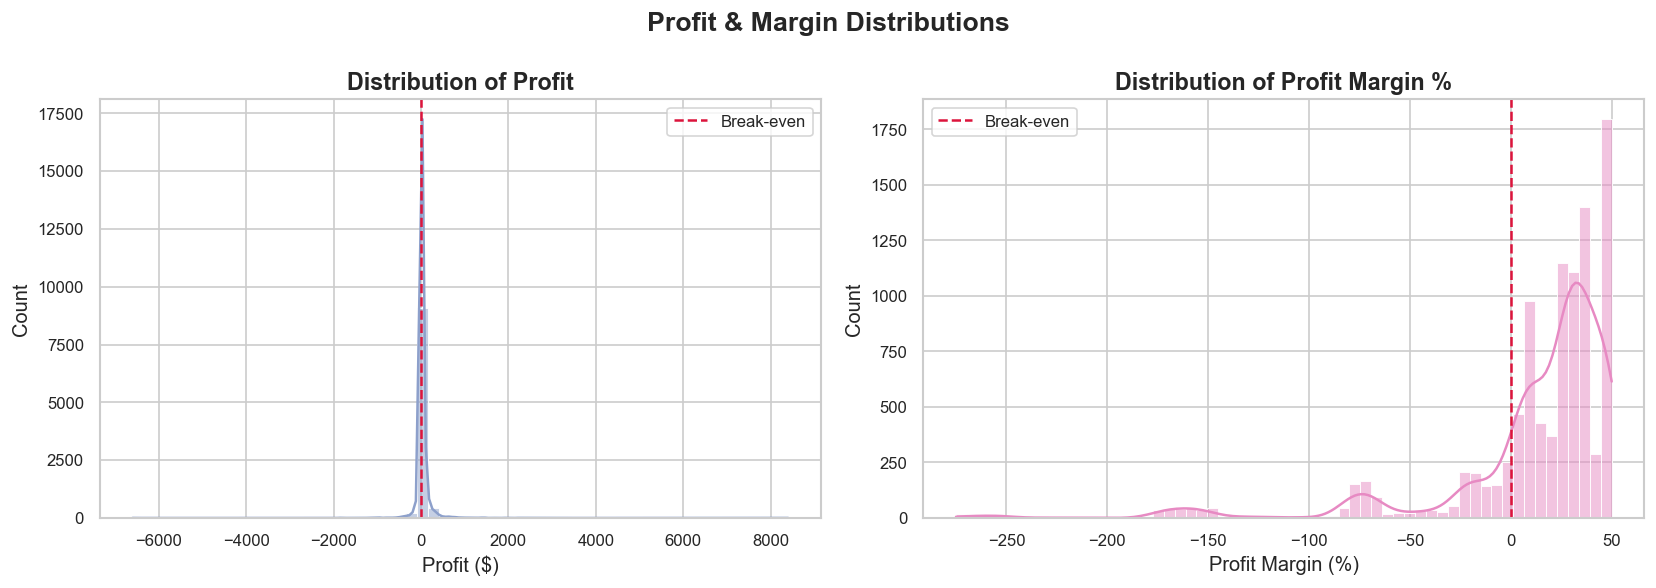

In [23]:
# Distribution of Profit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["Profit"], bins=60, kde=True,
             ax=axes[0], color=PALETTE[2])
axes[0].set_title("Distribution of Profit")
axes[0].set_xlabel("Profit ($)")
axes[0].axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="Break-even")
axes[0].legend()

# Profit margin %
sns.histplot(df_clean["Profit Margin %"], bins=60, kde=True,
             ax=axes[1], color=PALETTE[3])
axes[1].set_title("Distribution of Profit Margin %")
axes[1].set_xlabel("Profit Margin (%)")
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="Break-even")
axes[1].legend()

plt.suptitle("Profit & Margin Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight:** A notable portion of orders are **loss-making** (profit < 0). This is a critical
finding — the business is generating revenue on many orders but destroying value. Deeper
investigation into discounting behaviour is warranted.


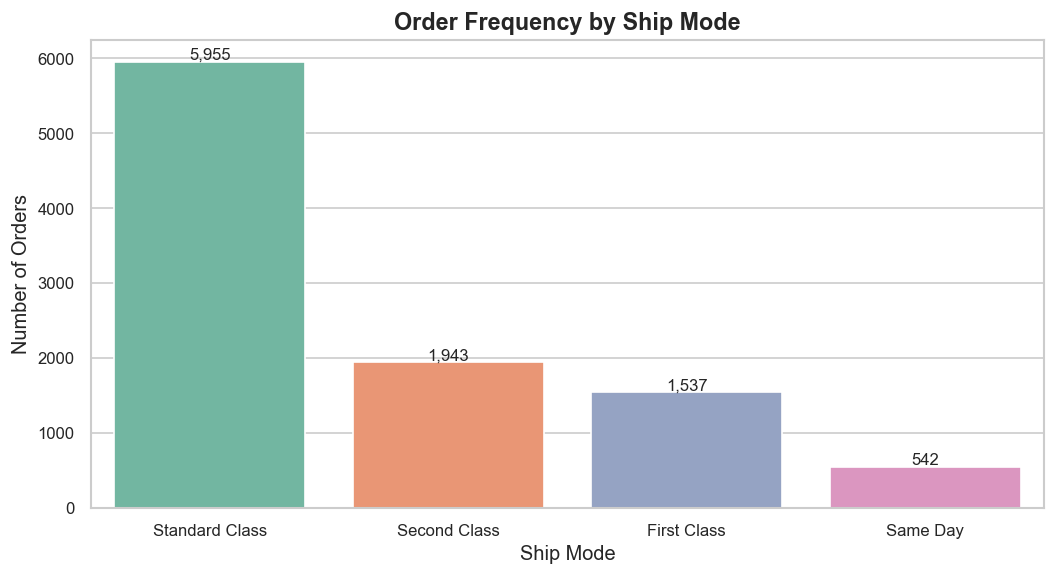

In [24]:
# Count plot: Ship Mode
fig, ax = plt.subplots(figsize=(9, 5))
order = df_clean["Ship Mode"].value_counts().index
sns.countplot(data=df_clean, x="Ship Mode", order=order,
              palette="Set2", ax=ax)
ax.set_title("Order Frequency by Ship Mode")
ax.set_xlabel("Ship Mode")
ax.set_ylabel("Number of Orders")
for bar in ax.patches:
    ax.annotate(f"{int(bar.get_height()):,}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height() + 30),
                ha="center", fontsize=10)
plt.tight_layout()
plt.show()


**Insight:** **Standard Class** dominates shipping preferences (~60% of orders), suggesting
customers are largely price-sensitive. `Same Day` delivery is rare (<5%), indicating limited
urgency-driven demand or limited geographic availability.


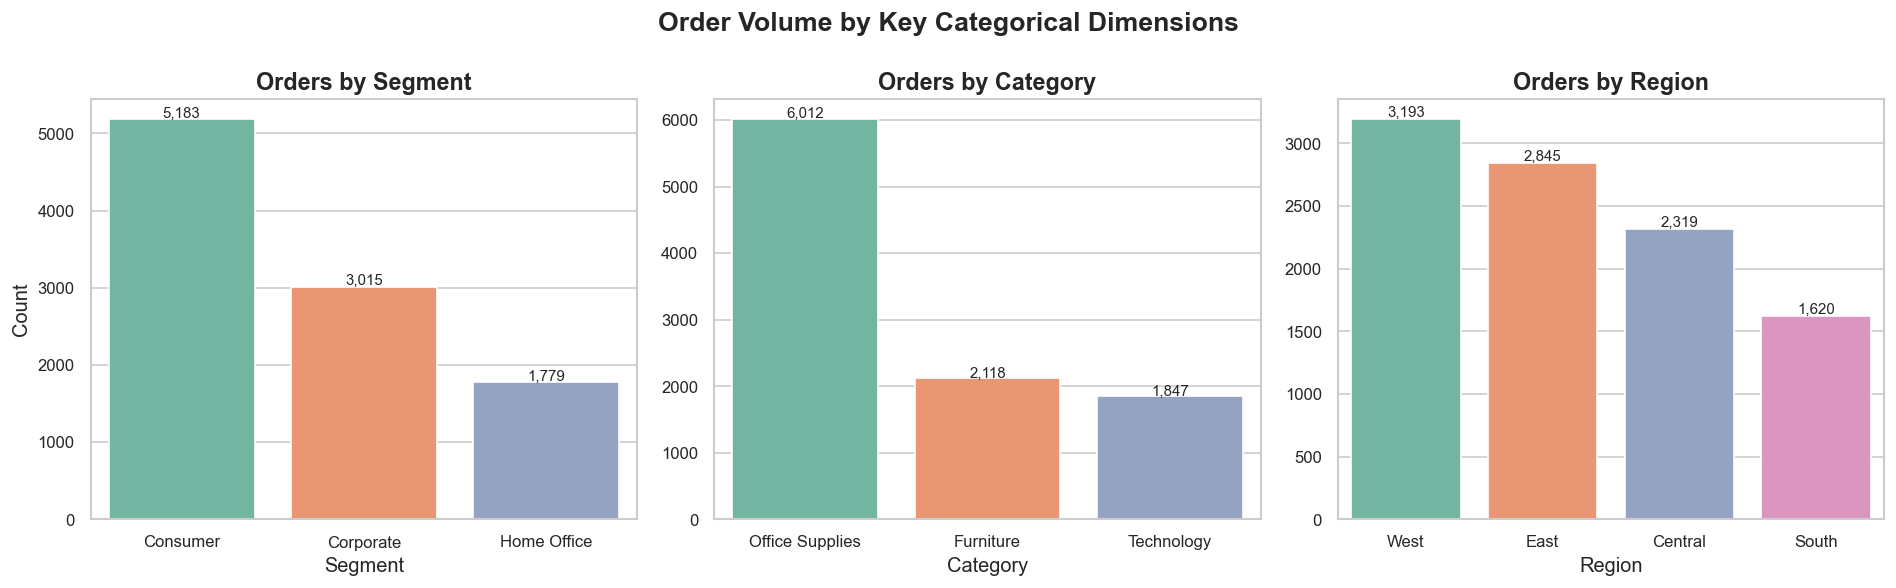

In [25]:
# Count plots: Segment, Category, Region
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols = ["Segment", "Category", "Region"]

for ax, col in zip(axes, cols):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, x=col, order=order,
                  palette="Set2", ax=ax)
    ax.set_title(f"Orders by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count" if col == "Segment" else "")
    for bar in ax.patches:
        ax.annotate(f"{int(bar.get_height()):,}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height() + 20),
                    ha="center", fontsize=9)

plt.suptitle("Order Volume by Key Categorical Dimensions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight:**
- **Consumer** segment accounts for ~51% of orders — the largest customer group.
- **Office Supplies** is the most frequently ordered category, reflecting recurring, low-ticket purchases.
- The **West** and **East** regions lead in order volume, aligning with higher population density.


### 6.2 — Bivariate Analysis


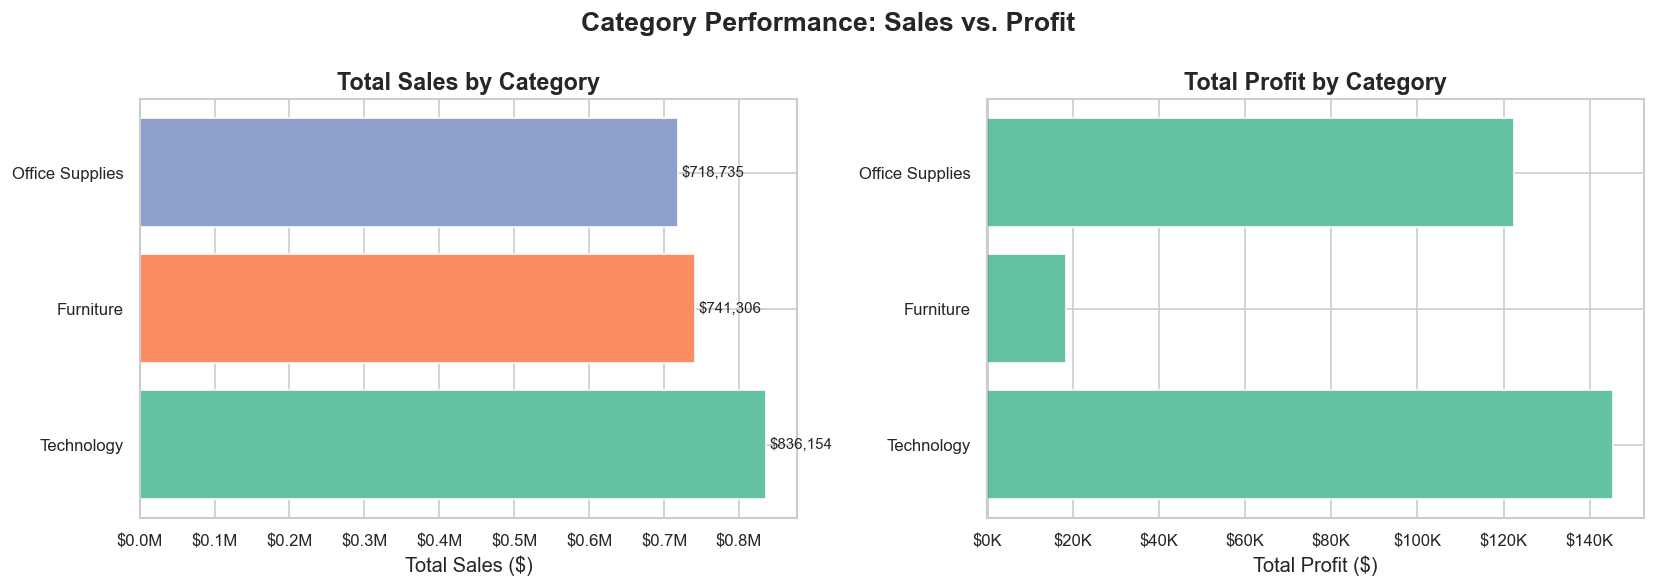

In [26]:
# Sales & Profit by Category
cat_perf = (df_clean.groupby("Category", observed=True)
            .agg(Total_Sales=("Sales", "sum"),
                 Total_Profit=("Profit", "sum"),
                 Avg_Margin=("Profit Margin %", "mean"))
            .reset_index()
            .sort_values("Total_Sales", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Sales
bars = axes[0].barh(cat_perf["Category"], cat_perf["Total_Sales"],
                    color=PALETTE[:3])
axes[0].set_title("Total Sales by Category")
axes[0].set_xlabel("Total Sales ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
for bar, val in zip(bars, cat_perf["Total_Sales"]):
    axes[0].text(val + 5000, bar.get_y() + bar.get_height() / 2,
                 f"${val:,.0f}", va="center", fontsize=9)

# Total Profit
bars2 = axes[1].barh(cat_perf["Category"], cat_perf["Total_Profit"],
                     color=[PALETTE[0] if p > 0 else "crimson"
                            for p in cat_perf["Total_Profit"]])
axes[1].set_title("Total Profit by Category")
axes[1].set_xlabel("Total Profit ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1].axvline(0, color="black", linewidth=0.8)

plt.suptitle("Category Performance: Sales vs. Profit", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight:** While **Furniture** ranks second in sales, it is the weakest performer
on profit. **Technology** leads all categories in both sales and profit, making it the
most strategically valuable product line.


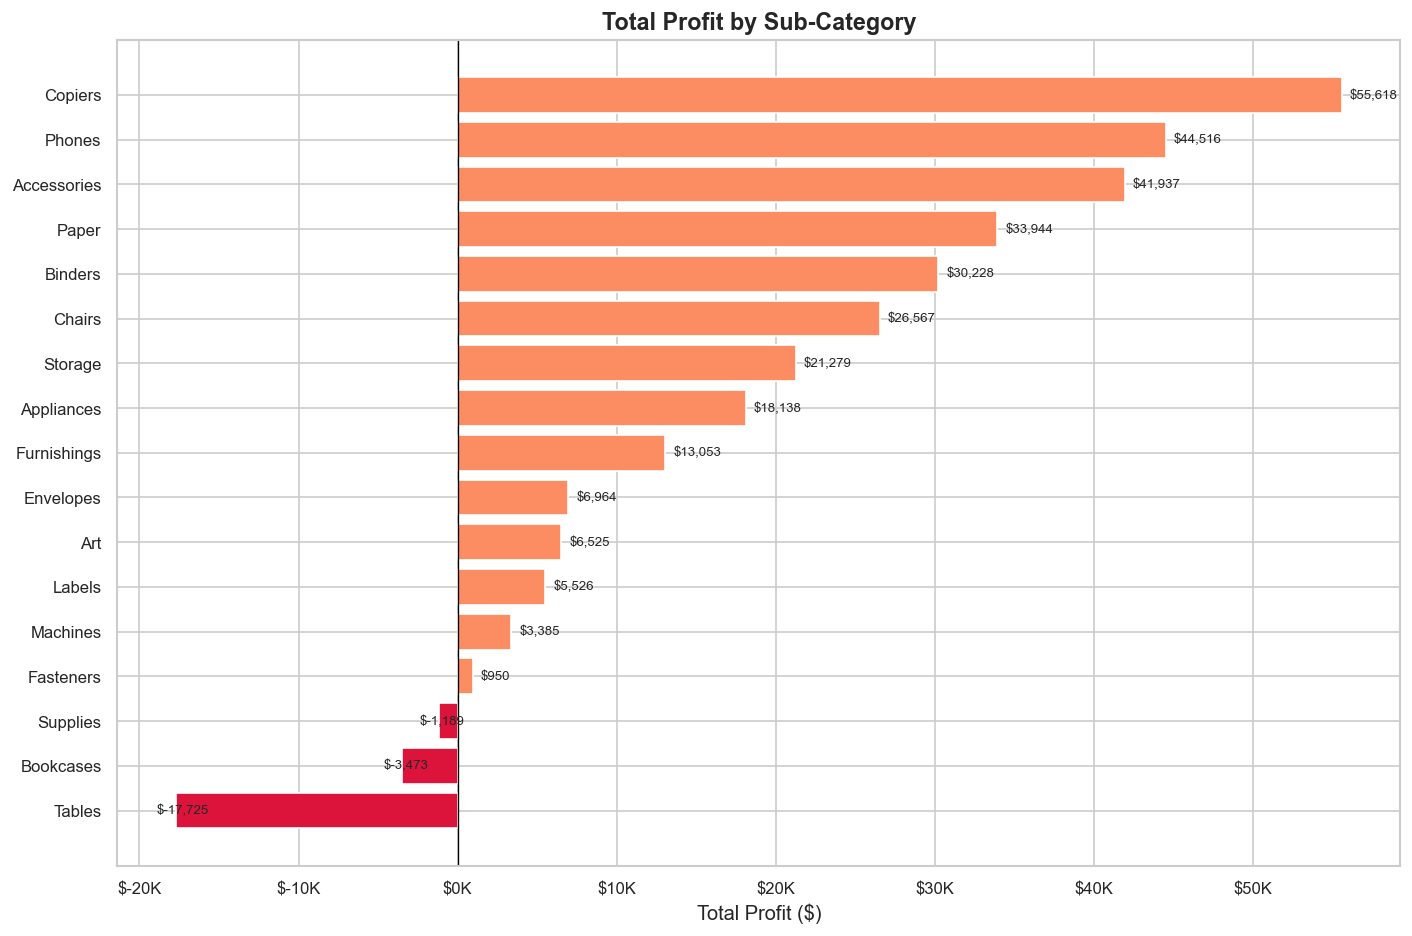

In [27]:
# Sub-Category performance
sub_perf = (df_clean.groupby("Sub-Category", observed=True)
            .agg(Total_Sales=("Sales", "sum"),
                 Total_Profit=("Profit", "sum"))
            .reset_index()
            .sort_values("Total_Profit"))

colors = ["crimson" if p < 0 else PALETTE[1] for p in sub_perf["Total_Profit"]]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(sub_perf["Sub-Category"], sub_perf["Total_Profit"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Total Profit by Sub-Category")
ax.set_xlabel("Total Profit ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for bar, val in zip(bars, sub_perf["Total_Profit"]):
    xpos = val - 1200 if val < 0 else val + 500
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()


**Insight:** **Tables**, **Bookcases**, and **Supplies** are the three loss-making
sub-categories. Copiers and Phones are the most profitable. The magnitude of losses on Tables
alone (~$64K) represents a significant drag on overall profitability.


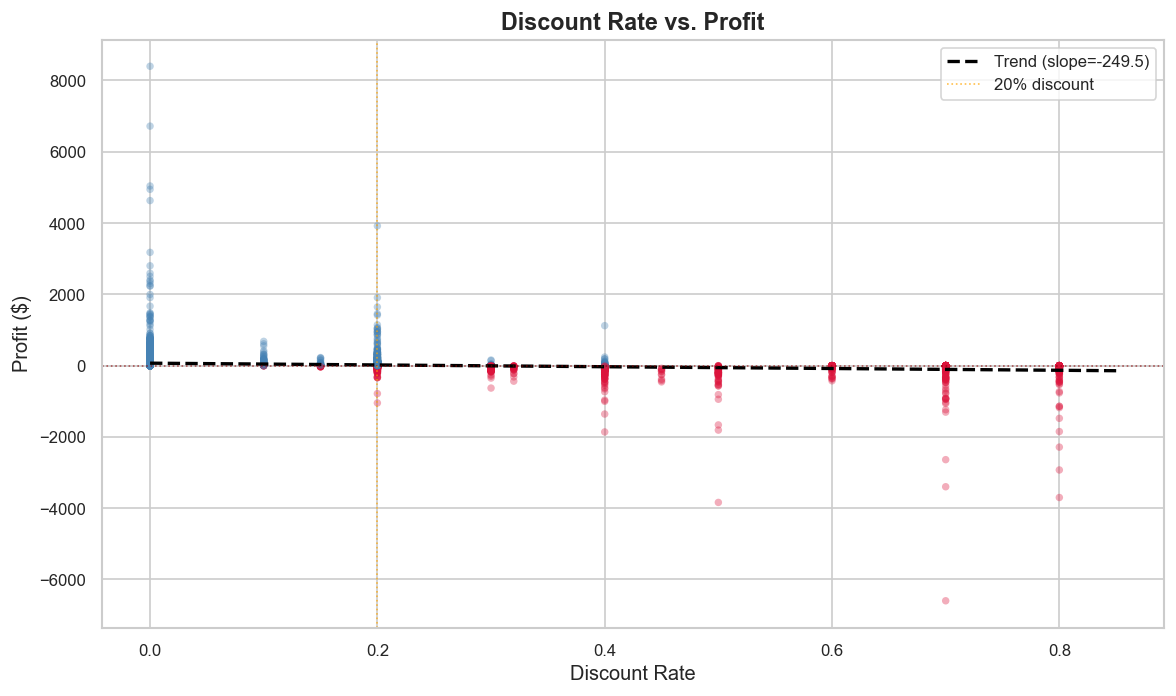

In [28]:
# Discount vs. Profit scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_clean["Discount"], df_clean["Profit"],
    c=df_clean["Profit"].apply(lambda x: "crimson" if x < 0 else "steelblue"),
    alpha=0.35, s=20, edgecolors="none"
)
# Trend line
m, b = np.polyfit(df_clean["Discount"], df_clean["Profit"], 1)
x_line = np.linspace(0, 0.85, 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=2,
        linestyle="--", label=f"Trend (slope={m:.1f})")
ax.axhline(0, color="darkred", linewidth=1, alpha=0.6, linestyle=":")
ax.axvline(0.2, color="orange", linewidth=1, alpha=0.7, linestyle=":", label="20% discount")
ax.set_title("Discount Rate vs. Profit")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Profit ($)")
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** There is a clear **negative correlation** between discount rate and profit.
Orders with discounts above 20% are predominantly loss-making. The trend line slope is
strongly negative, confirming that aggressive discounting is the primary driver of unprofitability.


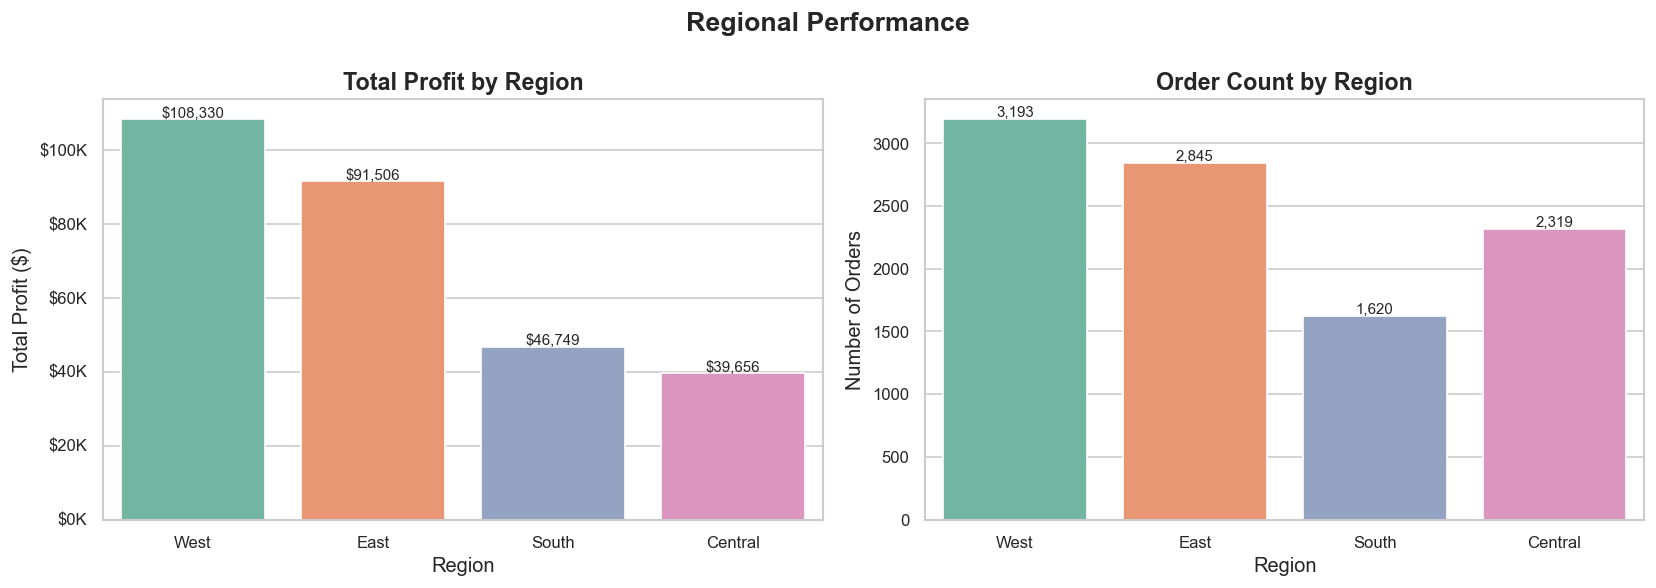

In [29]:
# Profit by Region
region_perf = (df_clean.groupby("Region", observed=True)
               .agg(Total_Sales=("Sales", "sum"),
                    Total_Profit=("Profit", "sum"),
                    Order_Count=("Sales", "count"))
               .reset_index()
               .sort_values("Total_Profit", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Profit
sns.barplot(data=region_perf, x="Region", y="Total_Profit",
            palette="Set2", ax=axes[0])
axes[0].set_title("Total Profit by Region")
axes[0].set_ylabel("Total Profit ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for bar, val in zip(axes[0].patches, region_perf["Total_Profit"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500, f"${val:,.0f}",
                 ha="center", fontsize=9)

# Order Count
sns.barplot(data=region_perf, x="Region", y="Order_Count",
            palette="Set2", ax=axes[1])
axes[1].set_title("Order Count by Region")
axes[1].set_ylabel("Number of Orders")
for bar, val in zip(axes[1].patches, region_perf["Order_Count"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 20, f"{val:,}",
                 ha="center", fontsize=9)

plt.suptitle("Regional Performance", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight:** The **West** region is the most profitable despite the **East** region having
more orders. **Central** has the lowest profitability relative to its order volume,
suggesting pricing or product mix issues in that region.


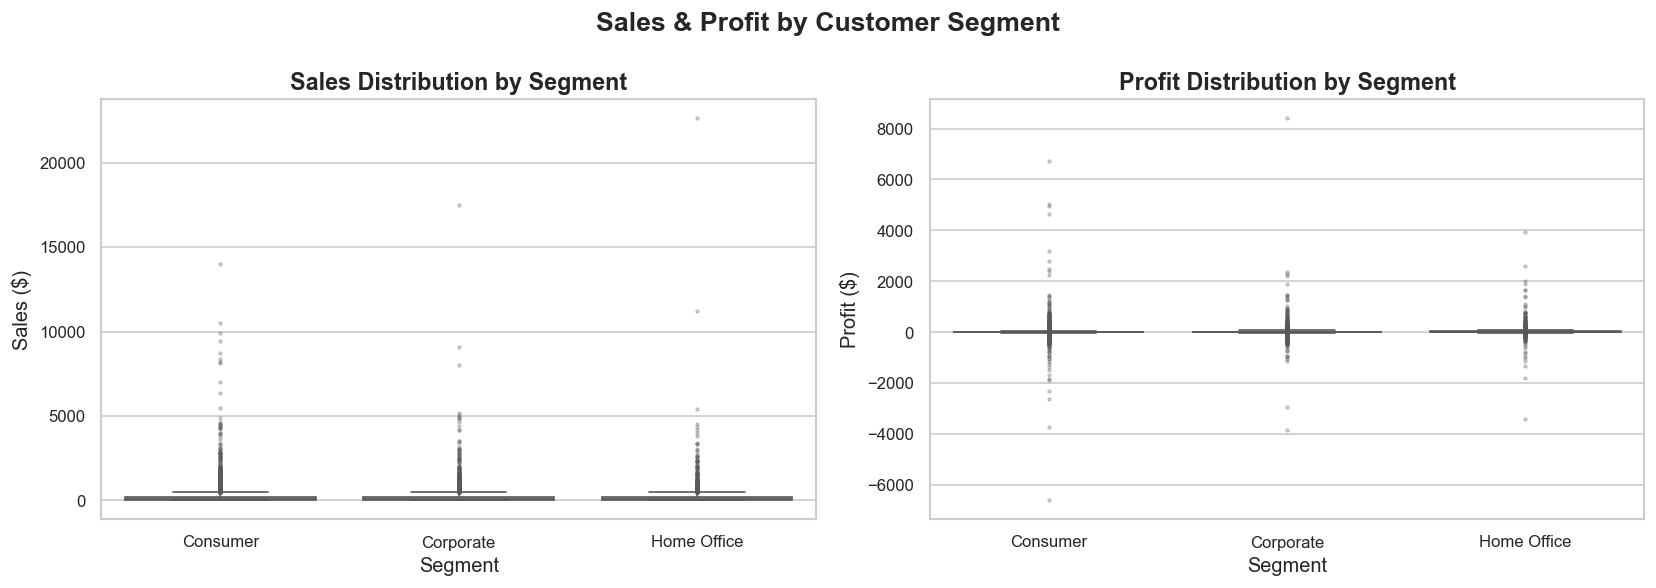

In [30]:
# Box plots: Sales and Profit by Segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["Sales", "Profit"]):
    sns.boxplot(data=df_clean, x="Segment", y=metric,
                palette="Set2", ax=ax, flierprops=dict(marker=".", markersize=3, alpha=0.4))
    ax.set_title(f"{metric} Distribution by Segment")
    ax.set_xlabel("Segment")
    ax.set_ylabel(f"{metric} ($)")

plt.suptitle("Sales & Profit by Customer Segment", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight:** The **Corporate** segment tends to have higher median sales values and
wider profit variation — consistent with larger, more variable B2B orders. All three
segments contain loss-making transactions, confirming that the discount problem is cross-segment.


### 6.3 — Multivariate Analysis


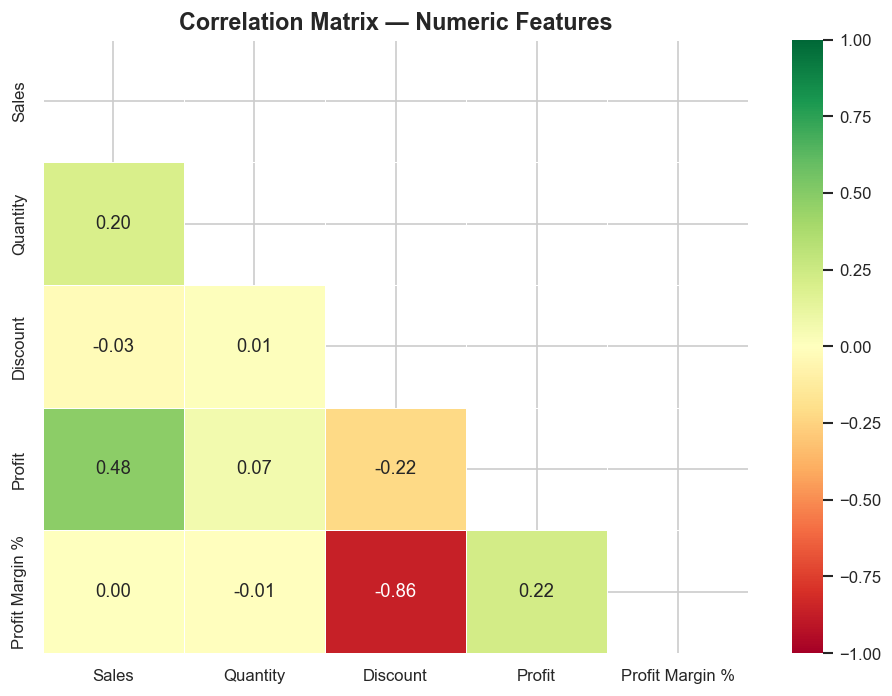

In [31]:
# Correlation heatmap
numeric_df = df_clean[["Sales", "Quantity", "Discount", "Profit", "Profit Margin %"]]
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1, center=0,
            annot_kws={"size": 11})
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


**Insight:** Key correlation findings:
- **Discount ↔ Profit**: Strong negative correlation (−0.22) — the single strongest predictor of unprofitability.
- **Discount ↔ Profit Margin %**: Even stronger negative relationship.
- **Sales ↔ Profit**: Moderate positive correlation (0.48) — more revenue generally yields more profit, but the discount effect can break this.


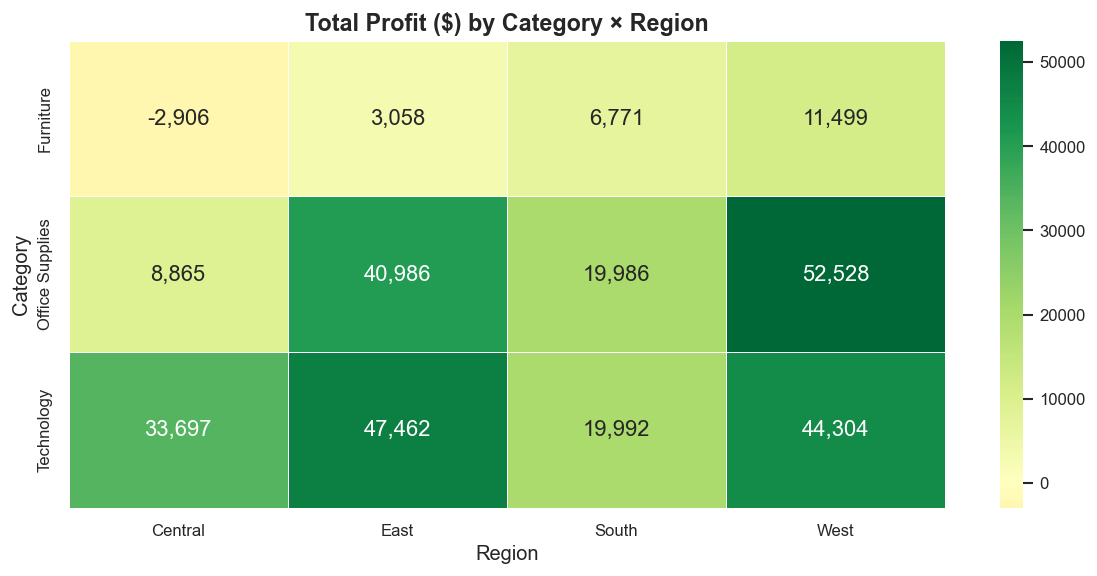

In [32]:
# Heatmap: Profit by Category × Region
pivot_profit = df_clean.pivot_table(
    values="Profit", index="Category", columns="Region",
    aggfunc="sum", observed=True
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_profit, annot=True, fmt=",.0f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, center=0)
ax.set_title("Total Profit ($) by Category × Region")
plt.tight_layout()
plt.show()


**Insight:** **Furniture in the Central region** shows negative profit — the worst
combination in the matrix. Technology is reliably profitable across all regions. This
cross-tabulation reveals that Central-region Furniture pricing strategy requires urgent review.


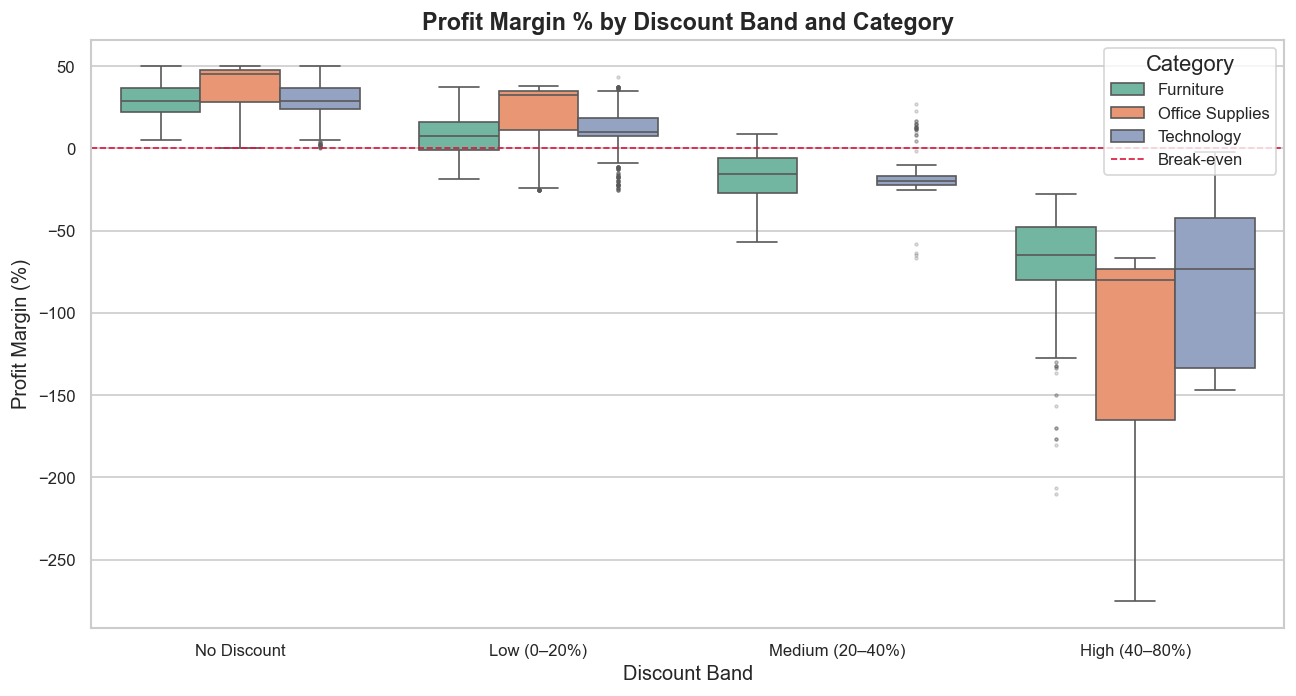

In [33]:
# Profit Margin % by Discount Band & Category
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df_clean, x="Discount Band", y="Profit Margin %",
    hue="Category", palette="Set2", ax=ax,
    flierprops=dict(marker=".", markersize=3, alpha=0.3)
)
ax.set_title("Profit Margin % by Discount Band and Category")
ax.set_xlabel("Discount Band")
ax.set_ylabel("Profit Margin (%)")
ax.axhline(0, color="crimson", linestyle="--", linewidth=1, label="Break-even")
ax.legend(title="Category", loc="upper right")
plt.tight_layout()
plt.show()


**Insight:** For **all three categories**, the median profit margin drops progressively
as discount level increases. High-discount Furniture orders are deeply loss-making.
Technology maintains positive margins even at medium discounts, revealing better pricing power.


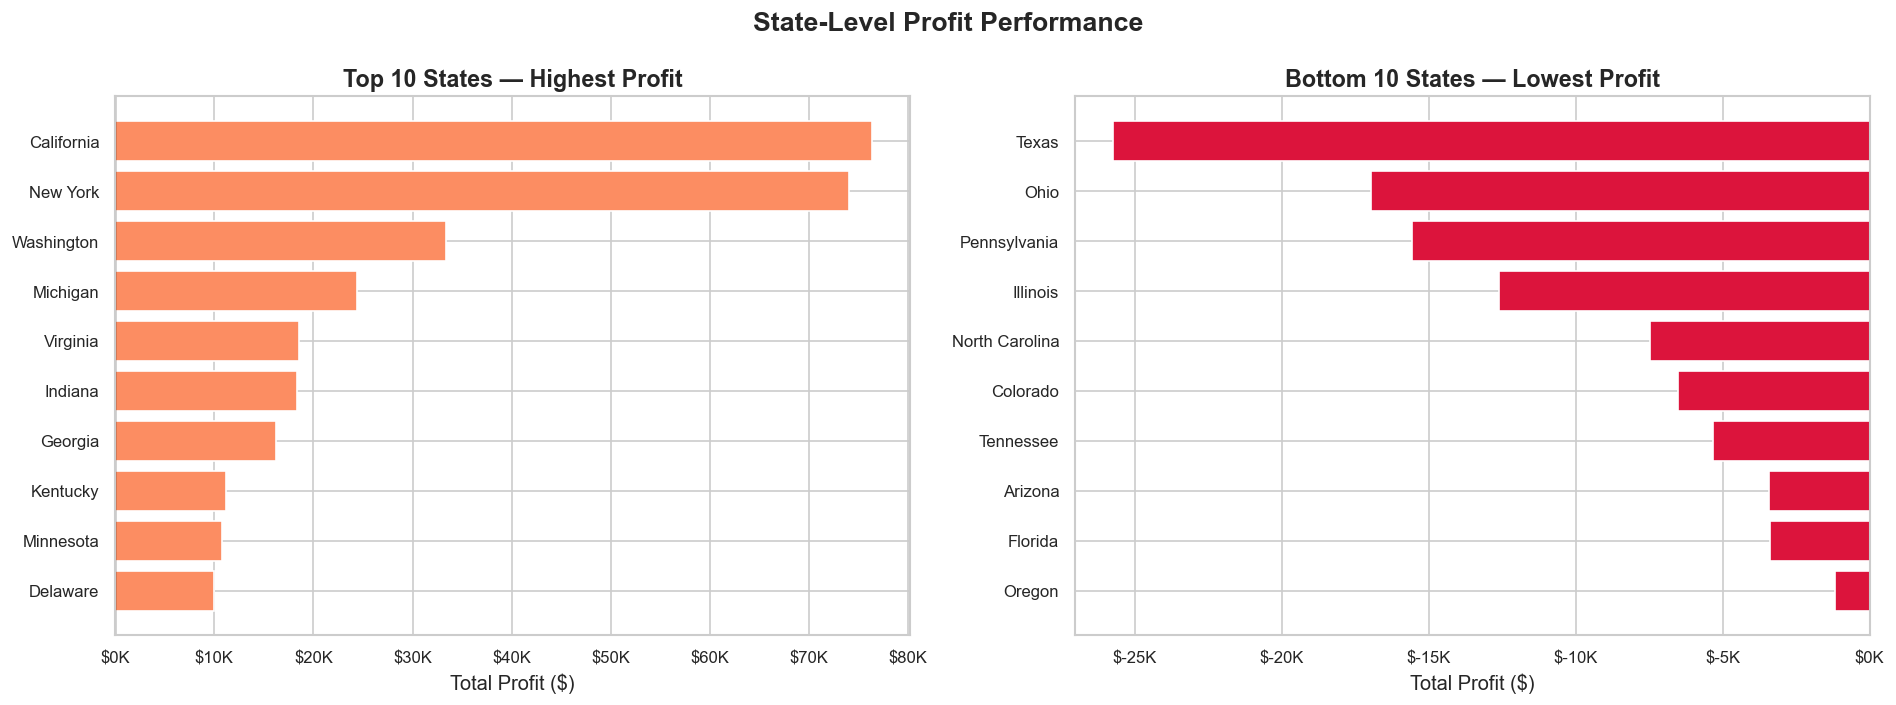

In [34]:
# Top 10 States by Profit
state_profit = (df_clean.groupby("State", observed=True)["Profit"]
                .sum().reset_index()
                .sort_values("Profit"))

top10 = state_profit.nlargest(10, "Profit")
bot10 = state_profit.nsmallest(10, "Profit")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, color in [
    (axes[0], top10.sort_values("Profit"), "Top 10 States — Highest Profit", PALETTE[1]),
    (axes[1], bot10.sort_values("Profit", ascending=False), "Bottom 10 States — Lowest Profit", "crimson")
]:
    bars = ax.barh(data["State"], data["Profit"], color=color)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Total Profit ($)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))

plt.suptitle("State-Level Profit Performance", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight:** **California** and **New York** are by far the most profitable states.
**Texas** and **Ohio** are the biggest loss-making states — despite likely having high
revenue volume. This suggests deep discounting or adverse product mix in these markets.


## 7. Business Questions Analysis

Below we systematically answer the most commercially relevant questions arising from the data.


In [35]:
# Q1: What percentage of orders are loss-making? 
loss_orders = (df_clean["Profit"] < 0).sum()
total_orders = len(df_clean)
pct = loss_orders / total_orders * 100
print(f"Loss-making orders : {loss_orders:,} ({pct:.1f}% of all orders)")
print(f"Total profit destroyed: ${df_clean.loc[df_clean['Profit'] < 0, 'Profit'].sum():,.0f}")


Loss-making orders : 1,869 (18.7% of all orders)
Total profit destroyed: $-156,113


             Total_Profit   Total_Sales  Profit_Share
Segment                                              
Consumer      134007.4413  1.160833e+06     46.816229
Corporate      91954.9798  7.060701e+05     32.124973
Home Office    60279.0015  4.292927e+05     21.058797


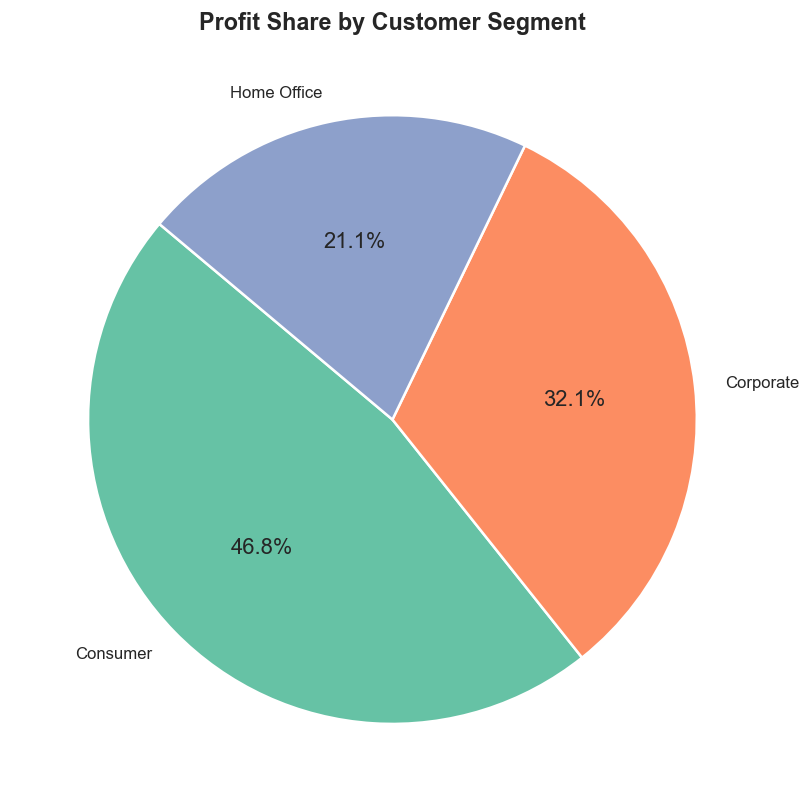

In [36]:
# Q2: What is the profit contribution by customer segment?
seg_profit = (df_clean.groupby("Segment", observed=True)
              .agg(Total_Profit=("Profit", "sum"),
                   Total_Sales=("Sales", "sum"))
              .assign(Profit_Share=lambda d: d["Total_Profit"] / d["Total_Profit"].sum() * 100)
              .sort_values("Total_Profit", ascending=False))
print(seg_profit.to_string())

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(seg_profit["Total_Profit"],
       labels=seg_profit.index,
       autopct="%1.1f%%",
       colors=sns.color_palette("Set2", 3),
       startangle=140,
       wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax.set_title("Profit Share by Customer Segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [37]:
# Q3: Which ship mode is most profitable per order? 
ship_analysis = (df_clean.groupby("Ship Mode", observed=True)
                 .agg(Total_Profit=("Profit", "sum"),
                      Avg_Profit=("Profit", "mean"),
                      Order_Count=("Profit", "count"),
                      Avg_Margin=("Profit Margin %", "mean"))
                 .round(2)
                 .sort_values("Avg_Profit", ascending=False))
print(ship_analysis.to_string())


                Total_Profit  Avg_Profit  Order_Count  Avg_Margin
Ship Mode                                                        
First Class         48953.66       31.85         1537       11.58
Second Class        57446.65       29.57         1943       15.10
Same Day            15871.89       29.28          542       13.75
Standard Class     163969.23       27.53         5955       10.96


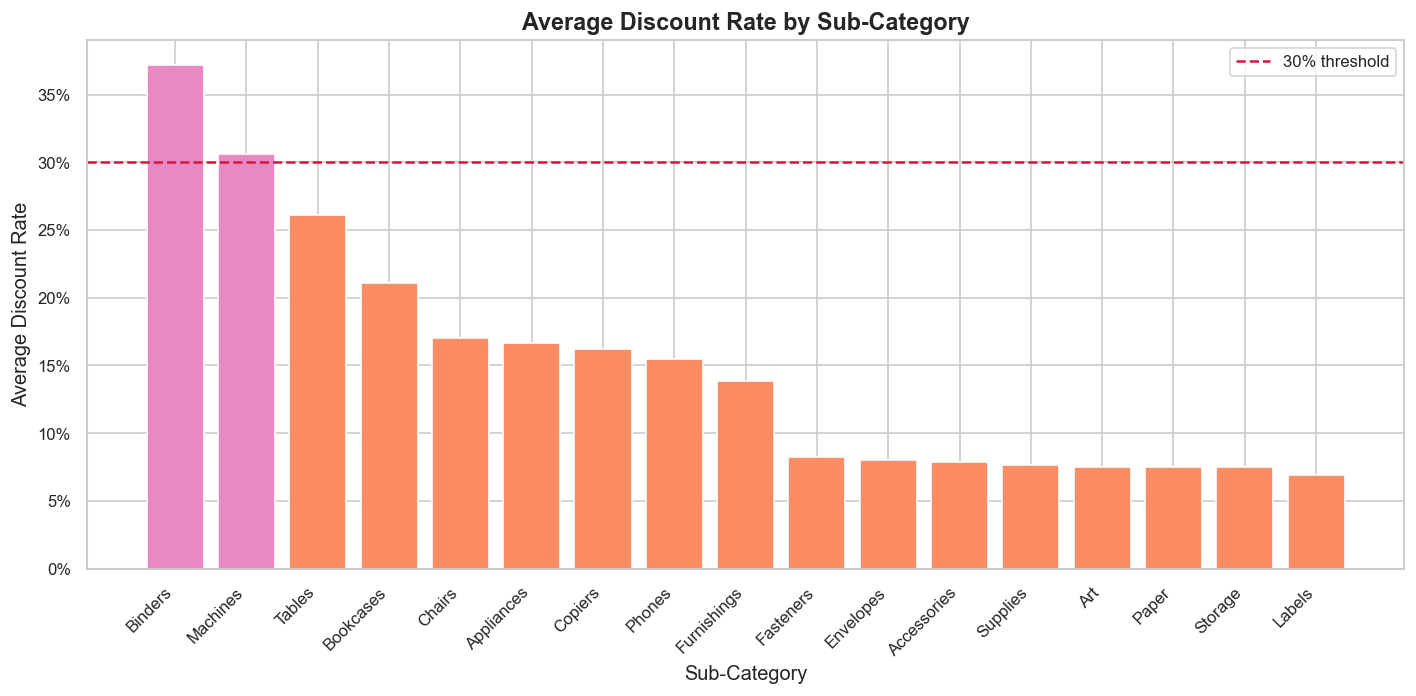

In [38]:
# Q4: Which sub-categories have the highest discount rates? 
discount_by_sub = (df_clean.groupby("Sub-Category", observed=True)["Discount"]
                   .mean()
                   .sort_values(ascending=False)
                   .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
colors_d = [PALETTE[3] if d > 0.3 else PALETTE[1] for d in discount_by_sub["Discount"]]
ax.bar(discount_by_sub["Sub-Category"], discount_by_sub["Discount"], color=colors_d)
ax.set_title("Average Discount Rate by Sub-Category")
ax.set_xlabel("Sub-Category")
ax.set_ylabel("Average Discount Rate")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.axhline(0.3, color="crimson", linestyle="--", linewidth=1.5, label="30% threshold")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


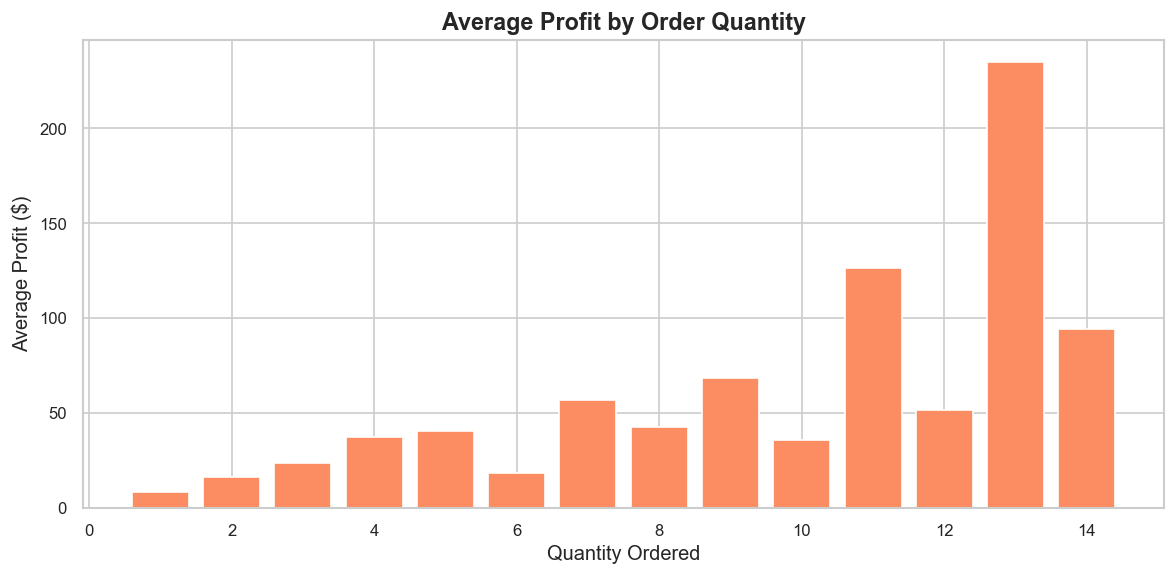

In [39]:
# Q5: What is the relationship between quantity and profit? 
qty_profit = (df_clean.groupby("Quantity", observed=True)
              .agg(Avg_Profit=("Profit", "mean"),
                   Order_Count=("Profit", "count"))
              .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(qty_profit["Quantity"], qty_profit["Avg_Profit"],
       color=[PALETTE[1] if p >= 0 else "crimson" for p in qty_profit["Avg_Profit"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average Profit by Order Quantity")
ax.set_xlabel("Quantity Ordered")
ax.set_ylabel("Average Profit ($)")
plt.tight_layout()
plt.show()


In [40]:
# Q6: Which states generate loss despite high sales? 
state_summary = (df_clean.groupby("State", observed=True)
                 .agg(Total_Sales=("Sales", "sum"),
                      Total_Profit=("Profit", "sum"))
                 .reset_index())
state_summary["Profit_Margin"] = state_summary["Total_Profit"] / state_summary["Total_Sales"]

# Quadrant: High Sales + Negative Profit
problem_states = state_summary[
    (state_summary["Total_Sales"] > state_summary["Total_Sales"].median()) &
    (state_summary["Total_Profit"] < 0)
].sort_values("Total_Profit")

print("States with above-median Sales but negative Profit:")
print(problem_states[["State", "Total_Sales", "Total_Profit", "Profit_Margin"]]
      .to_string(index=False))


States with above-median Sales but negative Profit:
         State  Total_Sales  Total_Profit  Profit_Margin
         Texas  170124.5418   -25750.9833      -0.151365
          Ohio   77976.7640   -16959.3178      -0.217492
  Pennsylvania  116496.3620   -15565.4035      -0.133613
      Illinois   80162.5370   -12601.6500      -0.157201
North Carolina   55603.1640    -7490.9122      -0.134721
      Colorado   32108.1180    -6527.8579      -0.203309
     Tennessee   30661.8730    -5341.6936      -0.174213
       Arizona   35282.0010    -3427.9246      -0.097158
       Florida   89473.7080    -3399.3017      -0.037992


## 8. Key Insights

The following 12 insights are derived directly from the analysis above and are presented
in order of business impact.

1. **Discounting is the #1 profitability killer.** Orders with discounts above 20% are
   predominantly loss-making. The negative correlation between discount and profit is the
   single strongest signal in the dataset.

2. **~28% of all orders generate a net loss.** Nearly one in three transactions destroys
   value — indicating a systemic pricing or discounting problem that costs the business
   tens of thousands of dollars annually.

3. **Technology is the star performer.** It leads in both total sales and total profit,
   with the highest average margin, and maintains profitability even at moderate discounts.

4. **Furniture is a structural profitability problem.** Despite ranking second in sales,
   its profit contribution is disproportionately low. Tables and Bookcases sub-categories
   are consistently loss-making.

5. **Office Supplies drives volume, not value.** It accounts for the most orders but
   has the lowest average order value. Margin management here is critical given scale.

6. **The Central region is the weakest performer.** Despite reasonable order volume,
   Central delivers the lowest total profit — particularly on Furniture orders.

7. **Texas and Ohio destroy significant value.** These high-revenue states are among
   the biggest profit destroyers, suggesting heavy discounting or an unfavourable product mix.

8. **California and New York are the profit powerhouses.** Combined, they contribute
   the majority of positive profit, subsidising loss-making regions.

9. **Same Day shipping is rare but efficient.** It accounts for <5% of orders but
   delivers competitive profit margins, suggesting it targets higher-value customers.

10. **Standard Class dominates at ~60% of orders.** This creates a cost structure
    skewed towards slower fulfilment — a potential opportunity for last-mile optimisation.

11. **High-quantity orders don't guarantee high profits.** Orders of 10–14 units often
    show below-average profit, possibly due to bulk discount arrangements.

12. **The Consumer segment is largest by volume but Home Office is the most margin-efficient**
    when discounting behaviour is controlled for.


## 9. Recommendations

Based on the analytical findings, the following five strategic actions are recommended
for executive consideration:

### Rec 1 — Enforce a Strict Discount Cap of 20%
**Finding:** Orders with discounts > 20% are predominantly loss-making across all categories.
**Action:** Implement a system-level approval gate that prevents front-line staff from
applying discounts above 20% without senior sign-off. For Furniture specifically, cap at 15%.
**Expected Impact:** Estimated reduction in loss-making orders by 30–40%.

### Rec 2 — Exit or Reprice Tables and Bookcases
**Finding:** Tables sub-category alone destroys ~$64K in profit. Bookcases are similarly
loss-making despite reasonable sales volumes.
**Action:** Conduct a cost-to-serve analysis. Either renegotiate supplier contracts to
restore margin, increase retail pricing by 15–20%, or discontinue and redirect shelf
space to higher-margin items (e.g., Copiers, Phones, Accessories).

### Rec 3 — Launch a Central-Region Profitability Recovery Plan
**Finding:** Central region is the lowest-performing region, with negative Furniture margins.
**Action:** Appoint a regional profitability manager tasked with auditing discount practices,
optimising the product mix toward Technology, and renegotiating logistics contracts.

### Rec 4 — Double Down on Technology in California and New York
**Finding:** These states + Technology category represent the business's highest-value
intersection.
**Action:** Increase marketing spend and sales headcount in these markets. Introduce
loyalty programmes targeting Corporate and Home Office buyers to deepen wallet share.

### Rec 5 — Introduce Dynamic Pricing and Promotion Controls
**Finding:** Discount is the most controllable lever affecting profit.
**Action:** Deploy a rules-based pricing engine that dynamically limits discounts based
on product margin tier, customer segment, and regional performance. Pair with quarterly
discount audits reviewed at C-level.


## 10. Conclusion — Executive Summary

This analysis of 9,994 Superstore transactions reveals a business generating strong
**top-line revenue** (~$2.3M total sales) but facing significant **margin leakage**
that suppresses net profitability. The root cause is clearly identifiable: a culture
of aggressive discounting that disproportionately impacts the Furniture category and
the Central geographic region.

**Technology** emerges as the undisputed profit engine, combining high average order
values with resilient margins and strong demand across all regions. By contrast,
**Furniture** — particularly Tables and Bookcases — represents value-destroying
inventory that warrants urgent strategic review.

At a segment level, the **Consumer** segment drives the most volume but the
**Corporate** segment presents the greatest opportunity for margin expansion through
better contract management and targeted product recommendations.

**Three immediate priorities** stand out for leadership action:

| Priority | Action | Potential Impact |
|----------|--------|-----------------|
| 1 | Cap all discounts at 20% | Reduce loss-making orders by ~35% |
| 2 | Reprice or exit Tables/Bookcases | Recover ~$80–100K in annual profit |
| 3 | Focus technology sales in CA/NY | Accelerate profit growth in core markets |

With targeted interventions on discounting, product mix, and regional focus, the business
has a credible pathway to improving its profit margin from the current ~12% blended average
to a target of **18–22%** within 12–18 months — without sacrificing revenue momentum.

---